## Setup for EDA and time series 

In [3]:
# Main data packages. 
import numpy as np
import pandas as pd
# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
import datetime
from datetime import timedelta
#
#
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

#from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing
#
# 

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100

### Columns
|Name                | Description                                                                   | Type     |
|---------------------|-------------------------------------------------------------------------------|----------|
| area       |                                |object |
| mtu     |                                   | object |
| biomass_mwh         |                      | float64 |
| fossil_brown_coal_mwh      |               | float64 |
| fossil_coal_derived_gas_mwh    |           | float64 |
| fossil_gas_mwh      |                    | float64 |
| fossil_hard_coal_mwh     |                | float64 |
| fossil_oil_mwh      |                     | float64 |
| fossil_oil_shale_mwh     |                 | float64 |
| fossil_peat_mwh     |                      | float64 |
| geothermal_mwh    |                       | float64 |
| hydro_pumped_storage_aggregated_mwh  |     | float64 |
| hydro_pumped_storage_consumption_mwh   |  | float64  |
| hydro_run_of_river_and_poundage_mwh   |    | float64 |
| hydro_water_reservoir_mwh  |               | float64 |
| marine_mwh     |                           | float64 |
| nuclear_mwh  |                             | float64 |
| other_mwh     |                            | float64 |
| other_renewable_mwh     |                 | float64 |
| solar_mwh     |                           | float64 |
| waste_mwh    |                             | float64 |
| wind_offshore_mwh    |                    | float6 |
| wind_onshore_mwh   |                       | float64 |
| date                  |                      | int64 |
| hour        |                                | int64 |
| total_energy_generation_mwh   |            | float64 |
| dtype: objectres_df.columns |

In [ ]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [4]:
# Import daataa
res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
res_df.tail()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
74874,Germany (DE),17.07.2023 18:00 - 17.07.2023 18:15 (CET/CEST),4136.0,6193.25,0.0,5510.00,2787.50,383.75,0.0,0.0,...,0.0,133.5,83.00,10084.25,895.25,3925.00,18271.00,20230717,18,54260.50
74875,Germany (DE),17.07.2023 19:00 - 17.07.2023 19:15 (CET/CEST),4179.0,7415.75,0.0,6561.00,2732.75,381.25,0.0,0.0,...,0.0,134.0,83.00,4724.00,903.00,4774.50,15783.75,20230717,19,49551.50
74876,Germany (DE),17.07.2023 20:00 - 17.07.2023 20:15 (CET/CEST),4215.5,7614.75,0.0,7294.00,2678.00,380.00,0.0,0.0,...,0.0,134.0,83.00,1511.25,908.00,4964.75,13085.75,20230717,20,44767.75
74877,Germany (DE),17.07.2023 21:00 - 17.07.2023 21:15 (CET/CEST),4261.0,7656.00,0.0,7201.75,2161.75,380.00,0.0,0.0,...,0.0,134.0,83.00,92.00,920.50,3792.25,11427.50,20230717,21,39940.75
74878,Germany (DE),17.07.2023 22:00 - 17.07.2023 22:15 (CET/CEST),1071.0,3828.25,0.0,3616.25,764.75,95.00,0.0,0.0,...,0.0,33.5,20.75,0.00,231.00,3022.25,5286.50,20230717,22,18434.25


In [327]:
#res_df.dtypes

In [328]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [5]:
# Create working copy of dataframe
data_df = res_df.copy()


# Convert timestamp to datetime object
# Extract additional features from timestamp column

data_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),01.01.2015 00:00 - 01.01.2015 00:15 (CET/CEST),3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,50545.5
1,Germany (DE),01.01.2015 01:00 - 01.01.2015 01:15 (CET/CEST),3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49530.0
2,Germany (DE),01.01.2015 02:00 - 01.01.2015 02:15 (CET/CEST),3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,48994.0
3,Germany (DE),01.01.2015 03:00 - 01.01.2015 03:15 (CET/CEST),4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48368.5
4,Germany (DE),01.01.2015 04:00 - 01.01.2015 04:15 (CET/CEST),4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48506.5


In [6]:
#df[['start_date', 'end_date']] = df['combined_data'].str.split('-', expand=True)
data_df['mtu']= data_df['mtu'].str.replace('(CET/CEST)', '')
data_df[['mtu_start', 'mtu_end']] = data_df['mtu'].str.split(' - ', expand=True)#.split(' - ')
data_df.columns = data_df.columns.str.strip()
#data_df.head()


In [7]:
data_df['mtu_start_date'] = data_df['mtu_start'].str.split(' ').str[0]
data_df['mtu_start_time'] = data_df['mtu_start'].str.split(' ').str[1]

data_df['mtu_end_date'] = data_df['mtu_end'].str.split(' ').str[0]
data_df['mtu_end_time'] = data_df['mtu_end'].str.split(' ').str[1]

data_df['mtu_start_time'] = data_df['mtu_start_time'].str.replace(":", ".")
data_df['mtu_end_time'] = data_df['mtu_end_time'].str.replace(":", ".")

data_df['mtu_end_time'] = data_df['mtu_end_time'].astype(float)
data_df['mtu_start_time'] = data_df['mtu_start_time'].astype(float)
data_df['mtu_delta_time'] = data_df['mtu_end_time'] - data_df['mtu_start_time']
#data_df['mtu_end_time'] = data_df['mtu_end_time'].apply(lambda x: timedelta(hours=int(x.split(':')[0]), minutes=int(x.split(':')[1])))
data_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,date,hour,total_energy_generation_mwh,mtu_start,mtu_end,mtu_start_date,mtu_start_time,mtu_end_date,mtu_end_time,mtu_delta_time
0,Germany (DE),01.01.2015 00:00 - 01.01.2015 00:15,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,20150101,0,50545.5,01.01.2015 00:00,01.01.2015 00:15,01.01.2015,0.0,01.01.2015,0.15,0.15
1,Germany (DE),01.01.2015 01:00 - 01.01.2015 01:15,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,20150101,1,49530.0,01.01.2015 01:00,01.01.2015 01:15,01.01.2015,1.0,01.01.2015,1.15,0.15
2,Germany (DE),01.01.2015 02:00 - 01.01.2015 02:15,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,20150101,2,48994.0,01.01.2015 02:00,01.01.2015 02:15,01.01.2015,2.0,01.01.2015,2.15,0.15
3,Germany (DE),01.01.2015 03:00 - 01.01.2015 03:15,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,20150101,3,48368.5,01.01.2015 03:00,01.01.2015 03:15,01.01.2015,3.0,01.01.2015,3.15,0.15
4,Germany (DE),01.01.2015 04:00 - 01.01.2015 04:15,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,20150101,4,48506.5,01.01.2015 04:00,01.01.2015 04:15,01.01.2015,4.0,01.01.2015,4.15,0.15


In [8]:
data_df['mtu_start_date'] = data_df['mtu_start'].str.split(' ').str[0]
data_df['mtu_start_time'] = data_df['mtu_start'].str.split(' ').str[1]

data_df['mtu_end_date'] = data_df['mtu_end'].str.split(' ').str[0]
data_df['mtu_end_time'] = data_df['mtu_end'].str.split(' ').str[1]

data_df['mtu_start_time'] = data_df['mtu_start_time'].str.replace(":", ".")
data_df['mtu_end_time'] = data_df['mtu_end_time'].str.replace(":", ".")
data_df['mtu_end_time'] = data_df['mtu_end_time'].astype(float)
data_df['mtu_start_time'] = data_df['mtu_start_time'].astype(float)
data_df['mtu_delta_time'] = data_df['mtu_end_time'] - data_df['mtu_start_time']
#data_df['mtu_end_time'] = data_df['mtu_end_time'].apply(lambda x: timedelta(hours=int(x.split(':')[0]), minutes=int(x.split(':')[1])))
data_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,date,hour,total_energy_generation_mwh,mtu_start,mtu_end,mtu_start_date,mtu_start_time,mtu_end_date,mtu_end_time,mtu_delta_time
0,Germany (DE),01.01.2015 00:00 - 01.01.2015 00:15,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,20150101,0,50545.5,01.01.2015 00:00,01.01.2015 00:15,01.01.2015,0.0,01.01.2015,0.15,0.15
1,Germany (DE),01.01.2015 01:00 - 01.01.2015 01:15,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,20150101,1,49530.0,01.01.2015 01:00,01.01.2015 01:15,01.01.2015,1.0,01.01.2015,1.15,0.15
2,Germany (DE),01.01.2015 02:00 - 01.01.2015 02:15,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,20150101,2,48994.0,01.01.2015 02:00,01.01.2015 02:15,01.01.2015,2.0,01.01.2015,2.15,0.15
3,Germany (DE),01.01.2015 03:00 - 01.01.2015 03:15,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,20150101,3,48368.5,01.01.2015 03:00,01.01.2015 03:15,01.01.2015,3.0,01.01.2015,3.15,0.15
4,Germany (DE),01.01.2015 04:00 - 01.01.2015 04:15,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,20150101,4,48506.5,01.01.2015 04:00,01.01.2015 04:15,01.01.2015,4.0,01.01.2015,4.15,0.15


In [347]:
#data_df= data_df.assign(
 #   timestamp = lambda x: pd.to_datetime(x['date']), 
#    datem = lambda x: x['date'].dt.date,
#    yearm = lambda x: x['date'].dt.year,
#    monthm = lambda x: x['date'].dt.month,
#)
data_df['date'] = pd.to_datetime(data_df['date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['year'] = data_df['date'].dt.year
data_df['month'] = data_df['date'].dt.month
data_df['day'] = data_df['date'].dt.day
data_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,mtu_start,mtu_end,mtu_start_date,mtu_start_time,mtu_end_date,mtu_end_time,mtu_delta_time,year,month,day
0,Germany (DE),01.01.2015 00:00 - 01.01.2015 00:15,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,01.01.2015 00:00,01.01.2015 00:15,01.01.2015,0.0,01.01.2015,0.15,0.15,2015,1,1
1,Germany (DE),01.01.2015 01:00 - 01.01.2015 01:15,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,01.01.2015 01:00,01.01.2015 01:15,01.01.2015,1.0,01.01.2015,1.15,0.15,2015,1,1
2,Germany (DE),01.01.2015 02:00 - 01.01.2015 02:15,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,01.01.2015 02:00,01.01.2015 02:15,01.01.2015,2.0,01.01.2015,2.15,0.15,2015,1,1
3,Germany (DE),01.01.2015 03:00 - 01.01.2015 03:15,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,01.01.2015 03:00,01.01.2015 03:15,01.01.2015,3.0,01.01.2015,3.15,0.15,2015,1,1
4,Germany (DE),01.01.2015 04:00 - 01.01.2015 04:15,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,01.01.2015 04:00,01.01.2015 04:15,01.01.2015,4.0,01.01.2015,4.15,0.15,2015,1,1


In [343]:
#data_df['date']

In [344]:
#data_df.columns

In [226]:
#data_df['mtu_end_date'] == data_df['mtu_start_date']
#data_df['mtu_end_time'] == data_df['mtu_start_time']

In [154]:
#data_df['mtu_start'].shape, data_df.shape,  data_df.columns
#df_sdt = data_df['mtu_start'].str.split(' ', expand=True)
#data_df.join(df_sdt)
#df_edt = data_df['mtu_end'].str.split(' ', expand=True)
#data_df.join(df_edt)
#data_df.rename(columns={'0': 'mtu_start_date'}, inplace=True)
#data_df.rename(columns={'1': 'mtu_start_time'}, inplace=True)
#data_df.rename(columns={'2': 'mtu_end_date'}, inplace=True)
#data_df.rename(columns={'3': 'mtu_end_time'}, inplace=True)#

OptionError: No such keys(s): 'mode.use_inf_as_null'

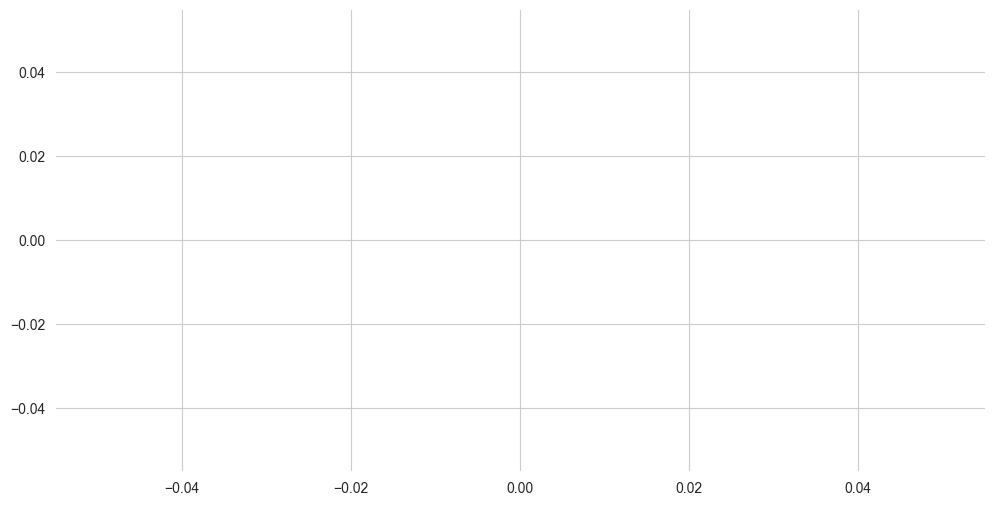

In [10]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='hour', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='tot_eneg_generation_versus_hour', ylabel='total_energy_generation_mwh');
fig.savefig("visualisations/tot_eneg_generation_versus_hour.png",dpi=300)

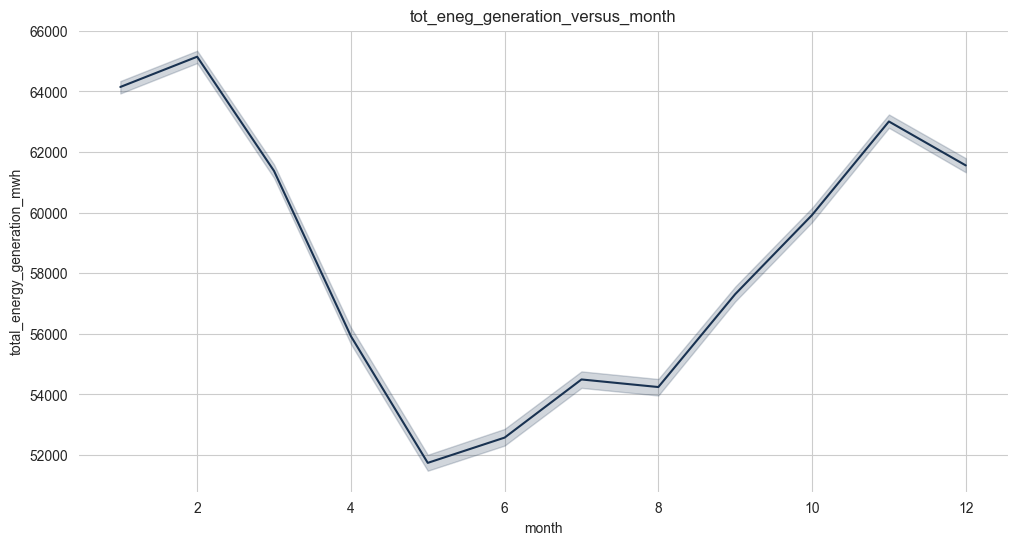

In [349]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='month', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='tot_eneg_generation_versus_month', ylabel='total_energy_generation_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_month.png",dpi=300)

In [1]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='year', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='tot_eneg_generation_versus_year', ylabel='total_energy_generation_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_year.png",dpi=300)

NameError: name 'plt' is not defined

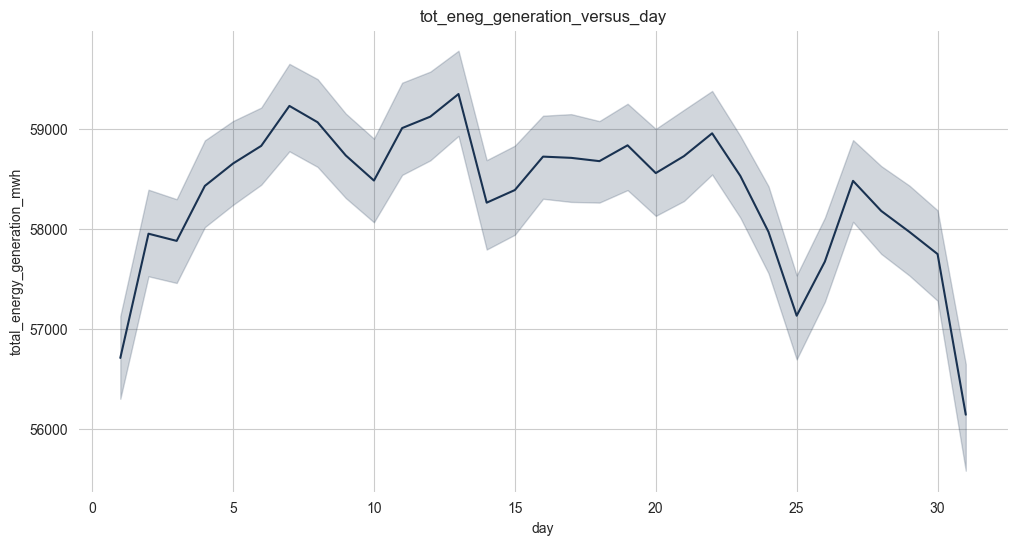

In [351]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='day', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='tot_eneg_generation_versus_day', ylabel='total_energy_generation_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_day.png",dpi=300)

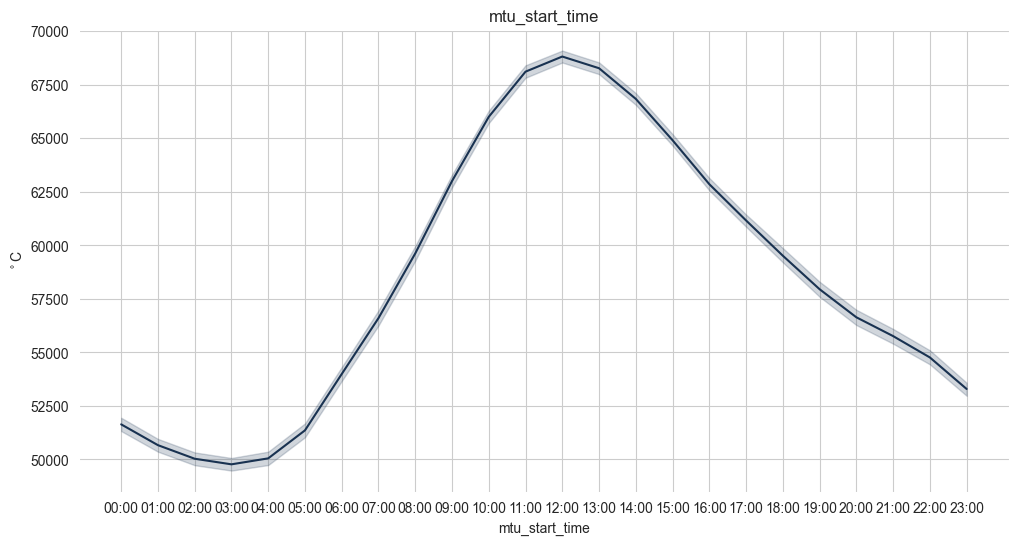

In [235]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='mtu_start_time', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='mtu_start_time', ylabel='total_energy_generation_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_mtu.png",dpi=300)

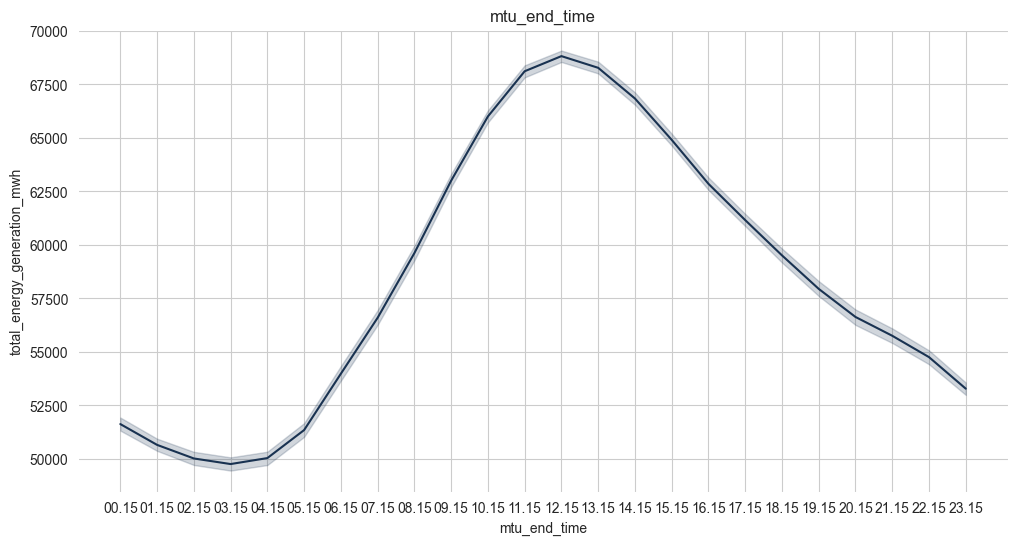

In [339]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='mtu_end_time', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='mtu_end_time', ylabel='total_energy_generation_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_mtu.png",dpi=300)

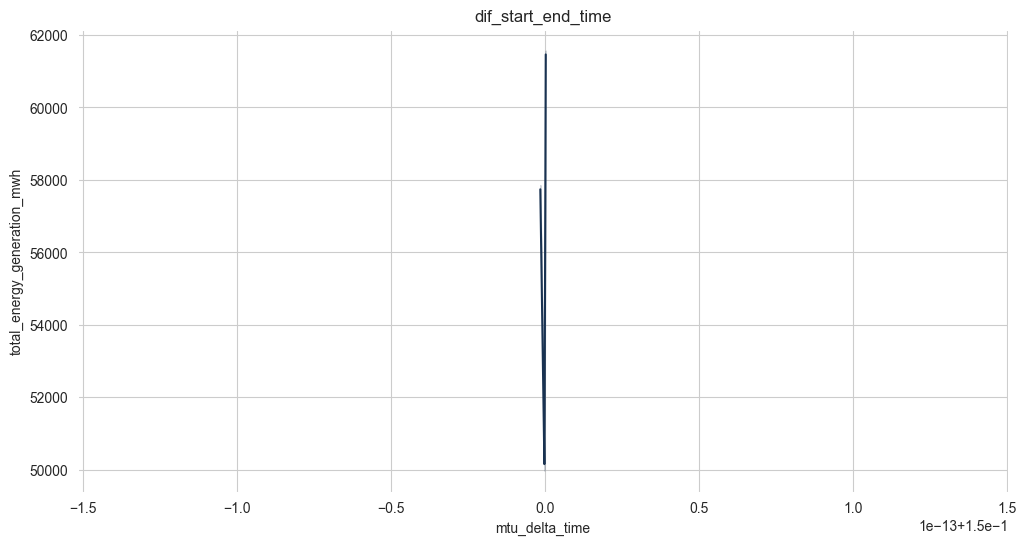

In [340]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='mtu_delta_time', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='dif_start_end_time', ylabel='total_energy_generation_mwh');
fig.savefig("visualisations/tot_eneg_generation_versus_difmtu.png",dpi=300)

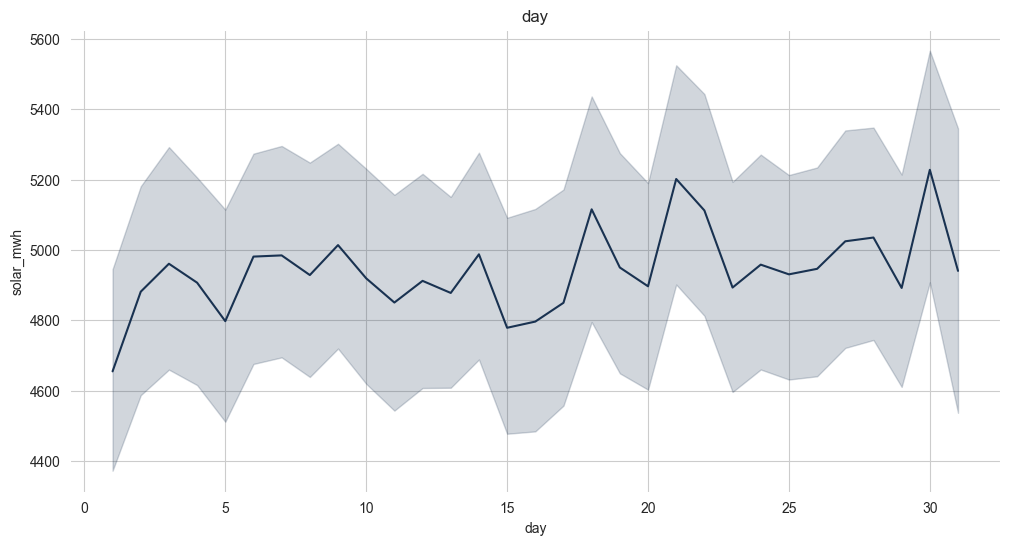

In [352]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='day', y='solar_mwh', data=data_df, ax=ax)
ax.set(title='day', ylabel='solar_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_mtu.png",dpi=300)

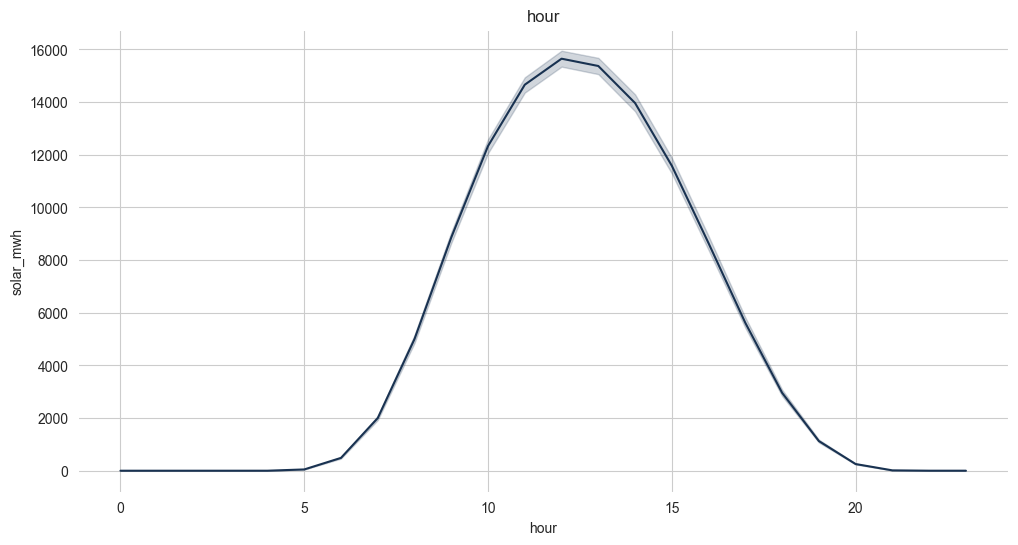

In [353]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='hour', y='solar_mwh', data=data_df, ax=ax)
ax.set(title='hour', ylabel='solar_mwh');


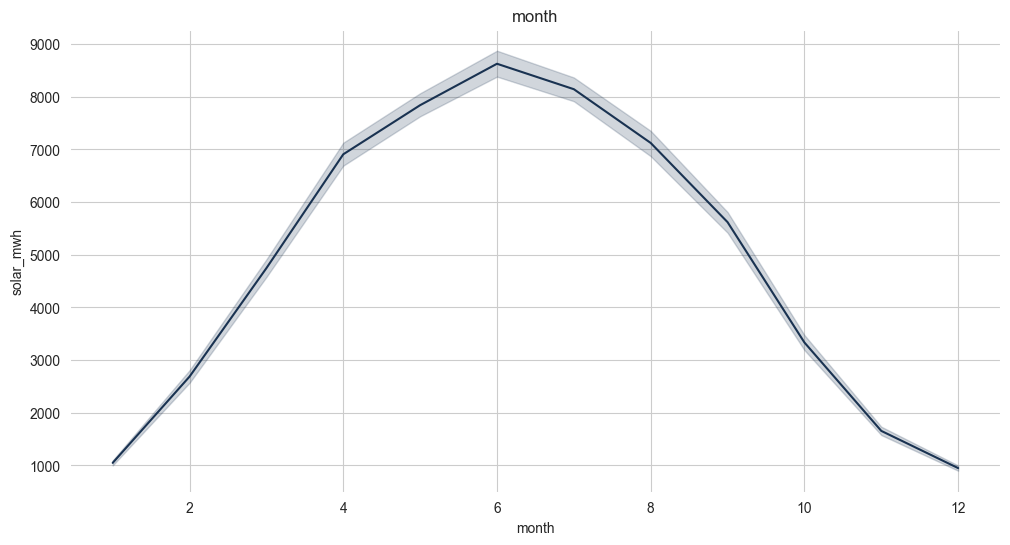

In [354]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='month', y='solar_mwh', data=data_df, ax=ax)
ax.set(title='month', ylabel='solar_mwh');


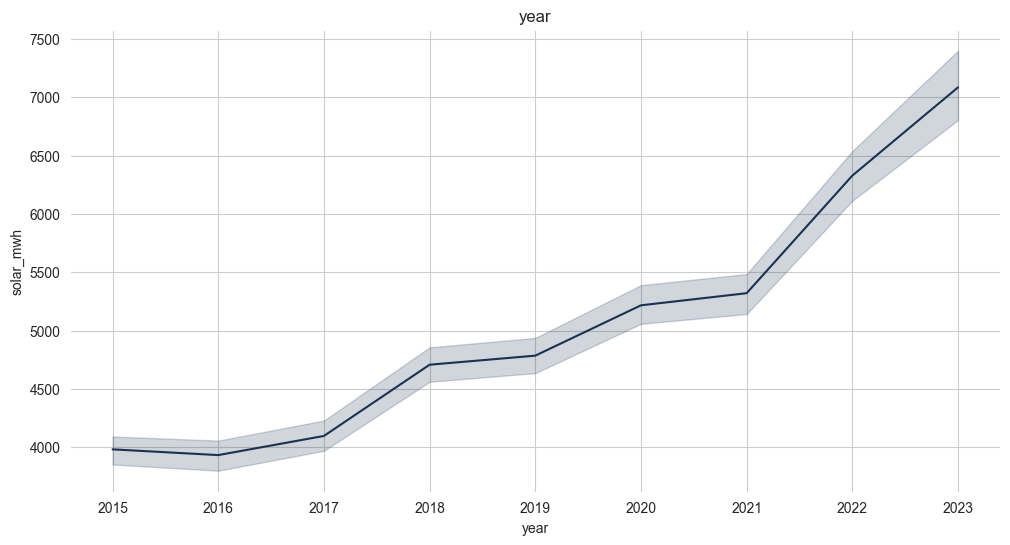

In [355]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='year', y='solar_mwh', data=data_df, ax=ax)
ax.set(title='year', ylabel='solar_mwh');


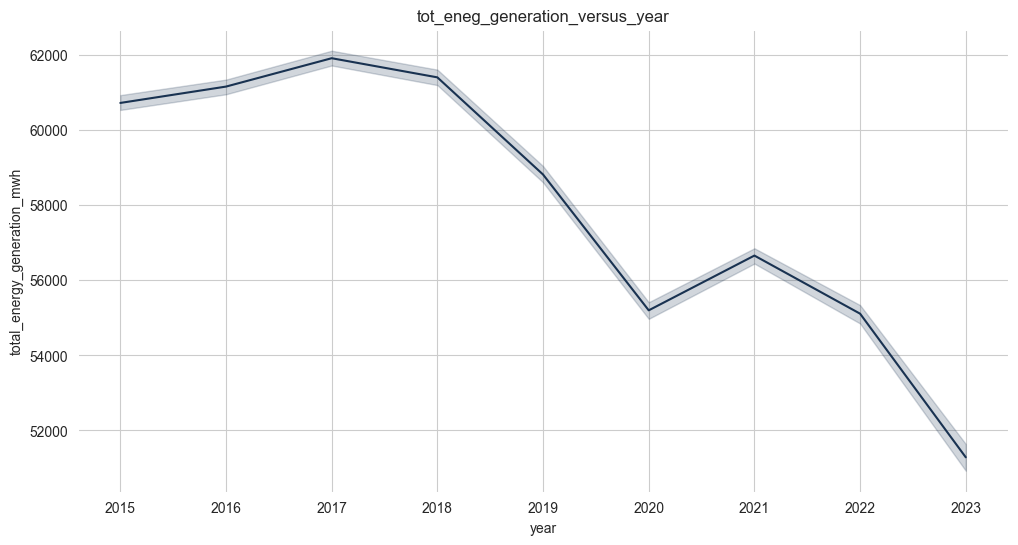

In [356]:
# Temperature hourly development over time 
fig, ax = plt.subplots()
sns.lineplot(x='year', y='total_energy_generation_mwh', data=data_df, ax=ax)
ax.set(title='tot_eneg_generation_versus_year', ylabel='total_energy_generation_mwh');

fig.savefig("visualisations/tot_eneg_generation_versus_year.png",dpi=300)